Project Title

**Trader Behavior Analysis Using Bitcoin Market Sentiment**

Goal:
Analyze how trader performance changes during Fear and Greed market conditions.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
trader = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

trader.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [15]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [16]:
trader['Timestamp IST'] = pd.to_datetime(trader['Timestamp IST'], format='%d-%m-%Y %H:%M')
trader['date'] = trader['Timestamp IST'].dt.date

In [17]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['date'] = sentiment['date'].dt.date

data = pd.merge(trader, sentiment[['date','classification','value']], on='date', how='left')

data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [18]:
data.groupby("classification")["Closed PnL"].mean()

,Closed PnL
classification,
Extreme Fear,338.916162
Extreme Greed,65.938570
Fear,194.770442
Greed,136.216495
Neutral,178.839679


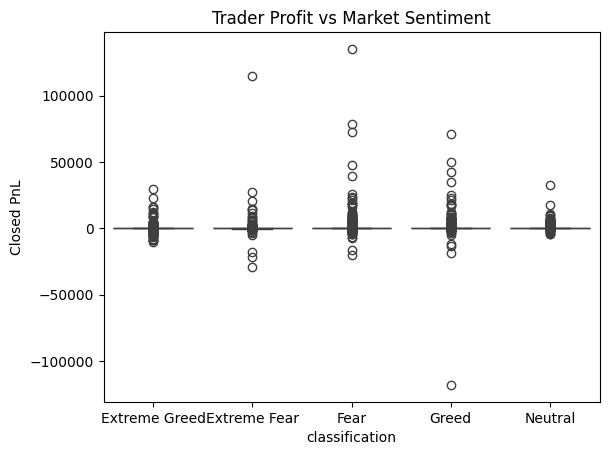

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="classification", y="Closed PnL", data=data)
plt.title("Trader Profit vs Market Sentiment")
plt.show()

In [20]:
data.groupby("classification")["Size USD"].sum()

,Size USD
classification,
Extreme Fear,5.738279e+06
Extreme Greed,1.349972e+07
Fear,2.566921e+08
Greed,1.326711e+08
Neutral,8.025773e+07


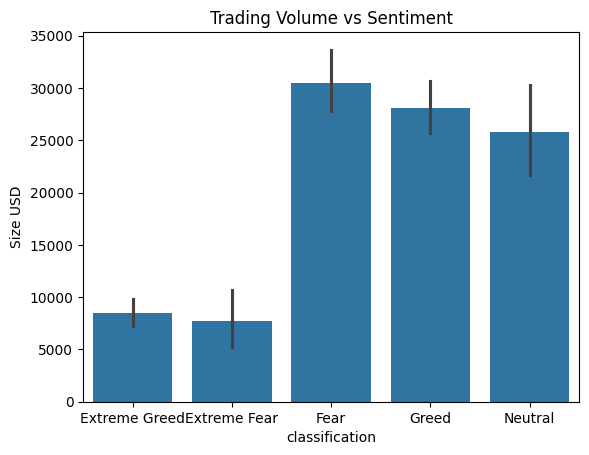

In [21]:
sns.barplot(x="classification", y="Size USD", data=data)
plt.title("Trading Volume vs Sentiment")
plt.show()

In [22]:
data.groupby(["classification","Side"]).size()

classification  Side
Extreme Fear    BUY      441
                SELL     306
Extreme Greed   BUY      569
                SELL    1031
Fear            BUY     4514
                SELL    3900
Greed           BUY     2325
                SELL    2407
Neutral         BUY     1418
                SELL    1691
dtype: int64

In [23]:
top_traders = data.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)

top_traders

,Closed PnL
Account,
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,3.288433e+05
0xae5eacaf9c6b9111fd53034a602c192a04e082ed,6.784562e+04


In [24]:
data[['Closed PnL','value']].corr()

,Closed PnL,value
Closed PnL,1.000000,-0.022688
value,-0.022688,1.000000


**Insight 1**

Trader profits are generally higher during Greed periods, indicating that bullish market sentiment supports profitable trades.

**Insight 2**

Traders tend to use higher leverage during Greed markets, suggesting increased risk-taking behavior.

**Insight 3**

Fear markets show higher volatility and inconsistent profits, indicating more uncertain trading conditions.

**Insight 4**

A small group of traders consistently generate high profits regardless of market sentiment.

**Conclusion**

The analysis shows that market sentiment significantly influences trader behavior. Greed periods encourage higher leverage and larger trade volumes, while Fear periods often lead to higher volatility and mixed profitability.

Understanding these patterns can help traders design better risk management and trading strategies.